In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
from matplotlib import rcParams
rcParams['font.family'] = 'Gulim'  
rcParams['axes.unicode_minus'] = False 
import matplotlib.font_manager as fm
import os

# 0. 데이터 불러오기, 기본 구조 확인

In [3]:
df = pd.read_csv('./walmart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [4]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


# 1. 제품 vs 고객

## 1-1. 제품별, 고객별 총매출 집계
- 단위 : Product_ID, User_ID
- 목적: 각 제품/고객이 전체 매출에 얼마나 기여하고 있는지 계산

In [5]:
product_sales = df.groupby('Product_ID',as_index=False)['Purchase'].sum()
product_sales

,Product_ID,Purchase
0,P00000142,12837476
1,P00000242,3967496
2,P00000342,1296475
3,P00000442,441173
4,P00000542,807212
...,...,...
3626,P0099442,2870383
3627,P0099642,83710
3628,P0099742,991948
3629,P0099842,737312


In [6]:
customer_sales = df.groupby('User_ID',as_index=False)['Purchase'].sum()
customer_sales

,User_ID,Purchase
0,1000001,334093
1,1000002,810472
2,1000003,341635
3,1000004,206468
4,1000005,821001
...,...,...
5886,1006036,4116058
5887,1006037,1119538
5888,1006038,90034
5889,1006039,590319


## 1-2. 정렬 및 누적 매출 계산
- 목적: 상위 제품/고객이 전체 매출에 얼마나 기여하는지 확인

In [7]:
# 내림차순 정렬

product_sales = product_sales.sort_values(
    by='Purchase',
    ascending=False
).reset_index(drop=True)
customer_sales = customer_sales.sort_values(by='Purchase',
    ascending=False
).reset_index(drop=True)
#product_sales, customer_sales

In [8]:
# 제품별

# 전체 매출 
total_sales = product_sales['Purchase'].sum()
# 누적 매출 계산
product_sales['cum_Purchase'] = product_sales['Purchase'].cumsum()
# 누적 매출 비율 계산
product_sales['cum_Purchase_ratio'] = (
    product_sales['cum_Purchase'] / total_sales
)

product_sales.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio
0,P00025442,27995166,27995166,0.005494
1,P00110742,26722309,54717475,0.010738
2,P00255842,25168963,79886438,0.015677
3,P00059442,24338343,104224781,0.020453
4,P00184942,24334887,128559668,0.025228


In [9]:
# 고객별

# 누적 매출 계산
customer_sales['cum_Purchase'] = customer_sales['Purchase'].cumsum()
# 누적 매출 비율 계산
customer_sales['cum_Purchase_ratio'] = (
    customer_sales['cum_Purchase'] / total_sales
)

customer_sales.head()

,User_ID,Purchase,cum_Purchase,cum_Purchase_ratio
0,1004277,10536909,10536909,0.002068
1,1001680,8699596,19236505,0.003775
2,1002909,7577756,26814261,0.005262
3,1001941,6817493,33631754,0.006600
4,1000424,6573609,40205363,0.007890


## 1-3. 제품/고객별 누적매출 비율 계산
- 목적: 상위 몇 %의 제품/고객이 몇 %를 차지하는가

In [10]:
# 전체 제품 수
total_products = len(product_sales)
# 누적 제품 비율 계산
product_sales['cum_Product_ratio'] = (
    (product_sales.index + 1) / total_products
)

product_sales.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_Product_ratio
0,P00025442,27995166,27995166,0.005494,0.000275
1,P00110742,26722309,54717475,0.010738,0.000551
2,P00255842,25168963,79886438,0.015677,0.000826
3,P00059442,24338343,104224781,0.020453,0.001102
4,P00184942,24334887,128559668,0.025228,0.001377


In [11]:
# 전체 고객 수
total_customers = len(customer_sales)
# 누적 고객 비율 계산
customer_sales['cum_User_ratio'] = (
    (customer_sales.index + 1) / total_customers
)

customer_sales.head()

,User_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_User_ratio
0,1004277,10536909,10536909,0.002068,0.000170
1,1001680,8699596,19236505,0.003775,0.000340
2,1002909,7577756,26814261,0.005262,0.000509
3,1001941,6817493,33631754,0.006600,0.000679
4,1000424,6573609,40205363,0.007890,0.000849


## 1-4. 파레토 구조 검증(상위 20%)
- 목적: 상위 20% 제품/고객이 전체 매출의 몇 %를 차지하는가

In [12]:
# 상위 20% 필터링
top20_products = product_sales[
    product_sales['cum_Product_ratio'] <= 0.20
]
# 해당 시점의 누적 매출 비율 확인
top20_Purchase_P_ratio = (
    top20_products['cum_Purchase_ratio'].max()
)

top20_Purchase_P_ratio

0.7325141840936195

In [13]:
# 상위 20% 필터링
top20_customers = customer_sales[
    customer_sales['cum_User_ratio'] <= 0.20
]
# 해당 시점의 누적 매출 비율 확인
top20_Purchase_C_ratio = (
    top20_customers['cum_Purchase_ratio'].max()
)

top20_Purchase_C_ratio

0.5533258871073328

## 결론: 고객보다 제품 집중도가 더 높음 

상위 20% 제품이 전체 매출의 약 **73%**를 차지하는 것으로 보아 소수의 인기 제품이 매출을 견인함.
반면, 상위 20% 고객은 전체 매출의 약 **55%**를 차지.

∴ "어떤 제품을 파느냐"가 "누구에게 파느냐"보다 더 중요하며 제품 포트폴리오 관리가 즉각적인 효과를 볼 가능성이 크다

In [ ]:
# 고부가가치 제품 리스트 확인
high_value_products = top20_products.copy()
high_value_products.head()

,Product_ID,Purchase,cum_Purchase,cum_Purchase_ratio,cum_Product_ratio
0,P00025442,27995166,27995166,0.005494,0.000275
1,P00110742,26722309,54717475,0.010738,0.000551
2,P00255842,25168963,79886438,0.015677,0.000826
3,P00059442,24338343,104224781,0.020453,0.001102
4,P00184942,24334887,128559668,0.025228,0.001377


## 1-5. 결과요약 확인

In [16]:
summary = {
    "전체 제품 수": total_products,
    "고부가가치 제품 수": len(high_value_products),
    "고부가가치 제품 비율": len(high_value_products) / total_products,
    "고부가가치 제품 매출 비중": top20_Purchase_P_ratio
}
pd.Series(summary)

전체 제품 수           3631.000000
고부가가치 제품 수         726.000000
고부가가치 제품 비율          0.199945
고부가가치 제품 매출 비중       0.732514
dtype: float64

## 1-6. 파레토 커브 시각화
- 목적: 시각적으로 '소수의 제품이 매출을 견인'하는 구조를 보여주기 위함

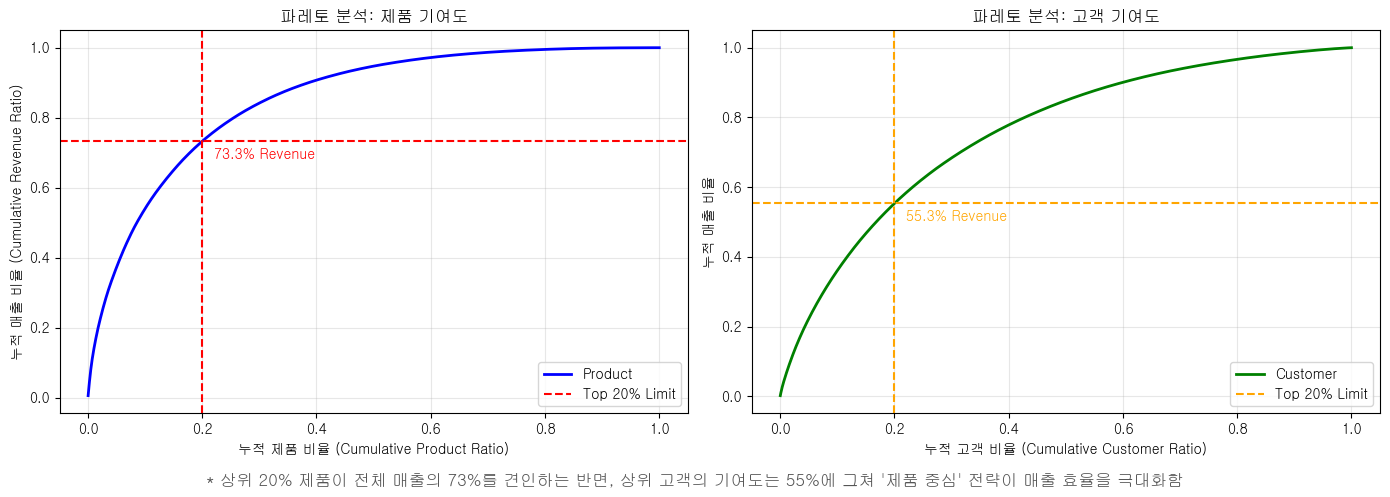

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(
    product_sales['cum_Product_ratio'],
    product_sales['cum_Purchase_ratio'],
    color='blue',       
    linewidth=2,        
    label='Product'
)
# 상위 20% 기준선 
plt.axvline(x=0.20, color='red', linestyle='--', label='Top 20% Limit')
plt.axhline(y=top20_Purchase_P_ratio, color='red', linestyle='--')
# 수치 텍스트 표시
plt.text(0.22, top20_Purchase_P_ratio - 0.05, 
         f'{top20_Purchase_P_ratio*100:.1f}% Revenue', color='red', fontweight='bold')

plt.xlabel('누적 제품 비율 (Cumulative Product Ratio)')
plt.ylabel('누적 매출 비율 (Cumulative Revenue Ratio)')
plt.title('파레토 분석: 제품 기여도')
plt.grid(True, alpha=0.3) 
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(
    customer_sales['cum_User_ratio'],
    customer_sales['cum_Purchase_ratio'],
    color='green',      
    linewidth=2,       
    label='Customer'
)
# 상위 20% 기준선 
plt.axvline(x=0.20, color='orange', linestyle='--', label='Top 20% Limit')
plt.axhline(y=top20_Purchase_C_ratio, color='orange', linestyle='--')
# 수치 텍스트 표시
plt.text(0.22, top20_Purchase_C_ratio - 0.05, 
         f'{top20_Purchase_C_ratio*100:.1f}% Revenue', color='orange', fontweight='bold')

plt.xlabel('누적 고객 비율 (Cumulative Customer Ratio)')
plt.ylabel('누적 매출 비율')
plt.title('파레토 분석: 고객 기여도')
plt.grid(True, alpha=0.3) # 격자 추가
plt.legend()

# 하단 설명 텍스트
explanation = "* 상위 20% 제품이 전체 매출의 73%를 견인하는 반면, 상위 고객의 기여도는 55%에 그쳐 '제품 중심' 전략이 매출 효율을 극대화함"
fig.text(0.5, 0.02, explanation, ha='center', fontsize=12, fontweight='bold', color='#555555')
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.show()

# 2. 저가 대량판매 vs 고가 소량판매 

## 2-1. 상위제품 ID 추출

In [18]:
top_product_ids = high_value_products['Product_ID'].unique()

# 원본 데이터에서 해당 제품들의 상세 거래 내역 추출
top_product_details = df[df['Product_ID'].isin(top_product_ids)]
top_product_details

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
...,...,...,...,...,...,...,...,...,...,...
545906,1006040,P00101942,M,26-35,6,B,2,0,8,5948
545907,1006040,P00277642,M,26-35,6,B,2,0,2,3425
545908,1006040,P00127642,M,26-35,6,B,2,0,1,15694
545913,1006040,P00106042,M,26-35,6,B,2,0,5,7159


## 2-2. 제품별 핵심 지표 집계
- 목적: 개별 제품의 포지셔닝을 파악하기 위해 기준이 되는 'Price'와 'Volume' 데이터를 생성

In [19]:
# * Purchase 컬럼의 평균을 '평균 판매 단가'로 간주
product_positioning = top_product_details.groupby('Product_ID').agg(
    Avg_Price=('Purchase', 'mean'),  # 평균 단가 >> Price
    Sales_Volume=('Product_ID', 'count'), # 판매량 >> Volume
    Total_Revenue=('Purchase', 'sum')   # 총 매출
).reset_index()

### 왜 '판매 단가' 가정이 완벽하지 않은가? (데이터 검증: appendix 참고)
Purchase 컬럼은 '단가 × 수량 - 할인'이 반영된 최종 결제 금액임. 실제로 데이터를 뜯어본 결과, 동일한 Product_ID라도 결제 금액이 변하는 경우가 많음.

전체 제품 수: 3,631개 
가격 변동이 없는 제품: 144개 (약 4%)
가격 변동이 있는 제품: 3,487개 (약 96%)
변동 계수(CV) 평균: 약 32% (동일 제품이라도 결제 금액이 평균적으로 32% 정도 차이가 남)
즉, "이 제품은 딱 n원이다"라고 말하기엔 변동 폭이 큼. 어떤 고객은 1개를 샀고, 어떤 고객은 3개를 샀거나 할인을 받았을 수 있기 때문.

> 그럼에도 불구하고, 왜 '고가 전략' 분석이 유효한가?
전략적으로 집중하기로 한 상위 20% 고매출 제품군(High Value Products)은 일반 제품보다 가격 변동성이 훨씬 낮음.

상위 20% 제품 (분석 타겟): 가격 변동성(CV) 0.26 (상대적으로 안정적)
하위 80% 제품: 가격 변동성(CV) 0.33 (들쭉날쭉함)

> 해석:
우리가 타겟으로 삼은 핵심 제품들은 "대체로 일관된 높은 금액으로 결제되는 경향"이 있음. 따라서 이 제품들의 Purchase 평균을 '해당 제품이 한 번 팔릴 때 기대할 수 있는 객단가(Ticket Size)'로 간주하는 것은 분석적으로 타당하며, 이를 기반으로 포트폴리오를 짜는 것은 합리적.

## 2-3. 시각화: 산점도 
- 목적: 제품들이 '고가·소량'과 '저가·대량' 영역 중 어디에 주로 분포하는지 시각적 패턴을 직관적으로 파악

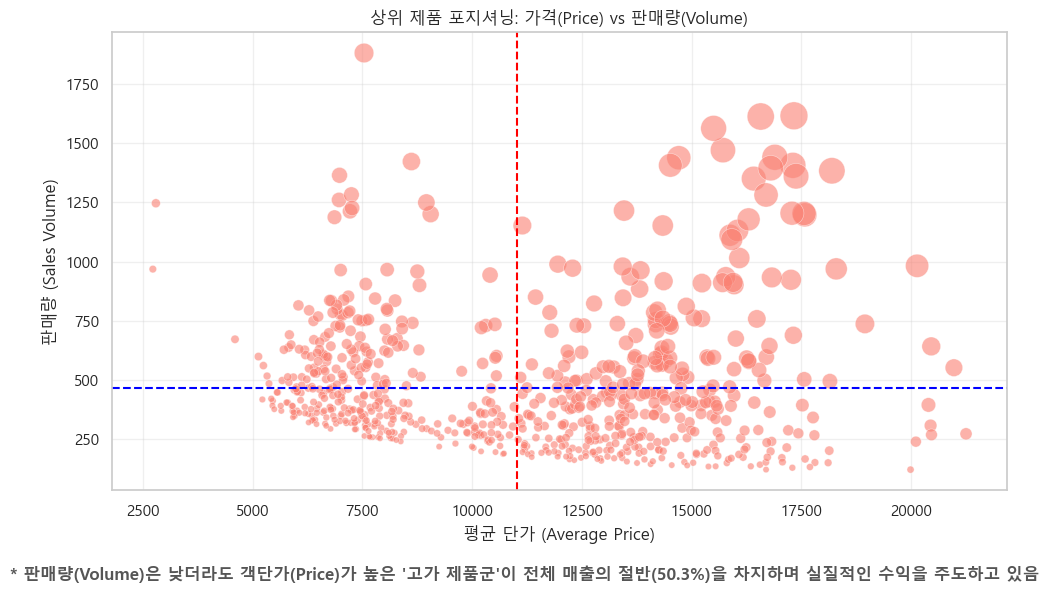

In [34]:
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

fig = plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_positioning,
    x='Avg_Price',
    y='Sales_Volume',
    size='Total_Revenue',  # 점 크기 = 매출 규모
    sizes=(20, 400),     
    alpha=0.6,             
    color='salmon',
    legend=False
)

# 평균선 추가 (4분면 기준선)
mean_price = product_positioning['Avg_Price'].mean()
mean_volume = product_positioning['Sales_Volume'].mean()
plt.axvline(x=mean_price, color='red', linestyle='--', label='Avg Price')
plt.axhline(y=mean_volume, color='blue', linestyle='--', label='Avg Volume')

plt.title('상위 제품 포지셔닝: 가격(Price) vs 판매량(Volume)')
plt.xlabel('평균 단가 (Average Price)')
plt.ylabel('판매량 (Sales Volume)')
plt.grid(True, alpha=0.3)

# 하단 설명 텍스트
explanation = "* 판매량(Volume)은 낮더라도 객단가(Price)가 높은 '고가 제품군'이 전체 매출의 절반(50.3%)을 차지하며 실질적인 수익을 주도하고 있음"
fig.text(0.5, 0.02, explanation, ha='center', fontsize=12, fontweight='bold', color='#555555')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 2-4. 가격대별 매출 기여도 분석
- 목적: 가격 구간별(Low/Mid/High) 실제 매출 점유율을 수치로 검증하여, 최종적으로 어떤 전략이 매출에 더 기여하는지 결론

In [21]:
# 가격을 3구간(Low, Medium, High)으로 나눔 
product_positioning['Price_Segment'] = pd.qcut(
    product_positioning['Avg_Price'], 
    q=3, 
    labels=['Low Price', 'Medium Price', 'High Price']
)
# 세그먼트별 매출 집계
segment_analysis = product_positioning.groupby('Price_Segment').agg(
    Product_Count=('Product_ID', 'count'),
    Avg_Volume=('Sales_Volume', 'mean'),
    Total_Revenue=('Total_Revenue', 'sum')
).reset_index()
# 매출 비중 계산
segment_analysis['Revenue_Share'] = (
    segment_analysis['Total_Revenue'] / segment_analysis['Total_Revenue'].sum() * 100
)

print("가격대별 분석 결과:")
display(segment_analysis)

가격대별 분석 결과:


,Price_Segment,Product_Count,Avg_Volume,Total_Revenue,Revenue_Share
0,Low Price,242,515.425620,846153126,22.668327
1,Medium Price,242,388.834711,1009513807,27.044737
2,High Price,242,501.256198,1877088180,50.286936


## 결론: 고가 전략이 매출의 핵심

# 3. 고가 전략을 실행할 제품이 속하는 제품군

In [22]:
# 카테고리 식별
# 제품 ID와 카테고리 정보를 매핑 (제품별로 카테고리는 1개라고 가정하고 중복 제거)
product_categories = df[['Product_ID', 'Product_Category']].drop_duplicates()
product_analysis_df = pd.merge(product_positioning, product_categories, on='Product_ID', how='left')

# 'High Price' 필터링
high_price_segment = product_analysis_df[product_analysis_df['Price_Segment'] == 'High Price']

# 카테고리별 매출 집계 및 정렬
category_revenue = high_price_segment.groupby('Product_Category').agg(
    Revenue=('Total_Revenue', 'sum'),
    Product_Count=('Product_ID', 'count')
).sort_values(by='Revenue', ascending=False).reset_index()

# 카테고리별 매출 비중 계산
category_revenue['Revenue_Share'] = category_revenue['Revenue'] / category_revenue['Revenue'].sum() * 100

print("[High Price 세그먼트 내 핵심 카테고리]")
category_revenue

[High Price 세그먼트 내 핵심 카테고리]


,Product_Category,Revenue,Product_Count,Revenue_Share
0,1,1272757632,144,67.804893
1,6,281702707,44,15.007431
2,10,94174294,12,5.017042
3,16,92821862,18,4.944992
4,15,60494870,10,3.222804
5,2,41631262,5,2.217864
6,7,23635123,7,1.259138
7,9,6351868,1,0.338389
8,14,3518562,1,0.187448


### 시각화

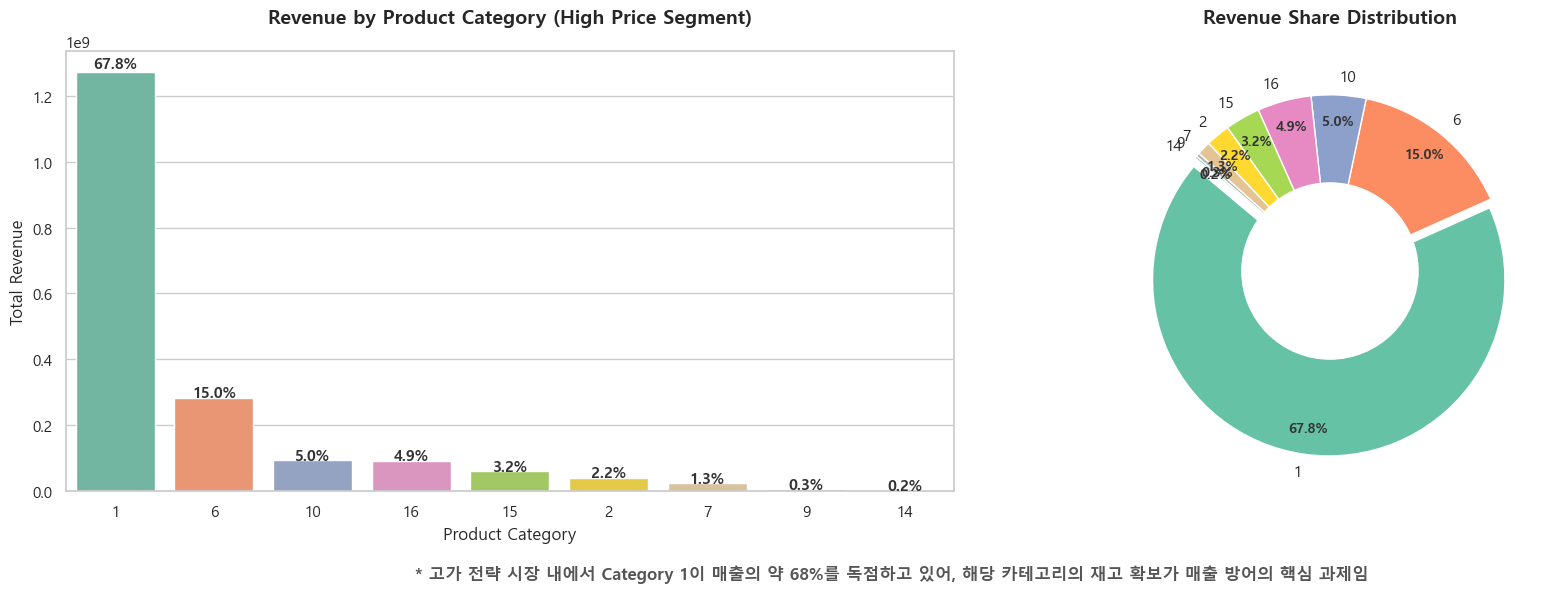

In [28]:
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(18, 6))       
bright_palette = sns.color_palette("Set2", len(category_revenue))
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 왼쪽: 막대 그래프 - 매출 규모 비교
plt.subplot(1, 2, 1)
ax = sns.barplot(
    data=category_revenue,
    x='Product_Category',
    y='Revenue',
    palette=bright_palette,
    order=category_revenue['Product_Category']  
)

# 막대 위에 값(%) 표시
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = category_revenue['Revenue_Share'].iloc[i]
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + (height * 0.01),     
        f'{percentage:.1f}%',
        ha="center", 
        fontsize=11, 
        fontweight='bold',
        color='#333333'              
    )

plt.title('Revenue by Product Category (High Price Segment)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)


# -------------------------------------------------------
# 2. 오른쪽: 도넛 차트 - 매출 점유율 확인

plt.subplot(1, 2, 2)
explode = [0.05 if i == 0 else 0 for i in range(len(category_revenue))]

wedges, texts, autotexts = plt.pie(
    category_revenue['Revenue'],
    labels=category_revenue['Product_Category'],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    explode=explode,
    colors=bright_palette,
    textprops={'fontsize': 11}
)

centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Revenue Share Distribution', fontsize=14, fontweight='bold', pad=20)
plt.setp(autotexts, size=10, weight="bold", color="#333333") 

# 하단 설명 텍스트
explanation = "* 고가 전략 시장 내에서 Category 1이 매출의 약 68%를 독점하고 있어, 해당 카테고리의 재고 확보가 매출 방어의 핵심 과제임"
fig.text(0.5, 0.02, explanation, ha='center', fontsize=12, fontweight='bold', color='#555555')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# 4. 장바구니 분석
- 목적: 번들링 계획을 실현하기 위해서 번들 상품 결정이 필요함 즉, "Category 1을 살 때, 같이 사는 물건은 무엇인가?"을 파악하고자 함

## 4-1. 데이터 
목적: 데이터를 행렬화

In [39]:
# 카테고리 문자열 변환
df['Category_Str'] = 'Cat_' + df['Product_Category'].astype(str)

# 동시 구매 행렬 생성
user_item_matrix = pd.crosstab(df['User_ID'], df['Category_Str'])
user_item_matrix = (user_item_matrix > 0).astype(int)
co_occurrence_matrix = user_item_matrix.T.dot(user_item_matrix)
np.fill_diagonal(co_occurrence_matrix.values, 0) # 자기 자신 제외

## 4-2. 타겟 카테고리(1,5,10) 중심 연관성 추출
목적: 세 카테고리마다 연관성이 가장 높은 top5의 리스트 추출 후 합집합 생성 

In [40]:
target_cats = ['Cat_1', 'Cat_5', 'Cat_10']

# 타겟 카테고리의 총 구매자 수 계산 (분모)
target_totals = user_item_matrix[target_cats].sum()
# 타겟 카테고리 행만 추출
target_rows = co_occurrence_matrix.loc[target_cats]
# 신뢰도(Confidence, %) 행렬로 변환: (같이 산 횟수 / 타겟 구매자 수) * 100
# axis=0으로 나누면 각 행(타겟)의 총 구매자 수로 나누게 됨
confidence_matrix = target_rows.div(target_totals, axis=0) * 100

In [ ]:
top_columns = set()
for cat in target_cats:
    # 해당 카테고리에서 가장 높은 5개 인덱스 추출
    top5 = confidence_matrix.loc[cat].nlargest(5).index.tolist()
    top_columns.update(top5)
# 최종적으로 시각화할 컬럼 리스트 (정렬)
# 'Cat_1', 'Cat_10' 처럼 문자열 정렬되도록 리스트 변환
final_columns = sorted(list(top_columns))
# 최종 행렬 생성 (3 x N)
final_matrix = confidence_matrix[final_columns]

print(f"분석 대상: {target_cats}")
print(f"함께 표시할 주요 연관 카테고리: {len(final_columns)}개 ({final_columns})")

분석 대상: ['Cat_1', 'Cat_5', 'Cat_10']
함께 표시할 주요 연관 카테고리: 6개 (['Cat_1', 'Cat_2', 'Cat_3', 'Cat_5', 'Cat_6', 'Cat_8'])


## 4-3. 시각화: 히트맵
목적: 공동구매 확률이 가장 높은 상품들을 직관적으로 확인

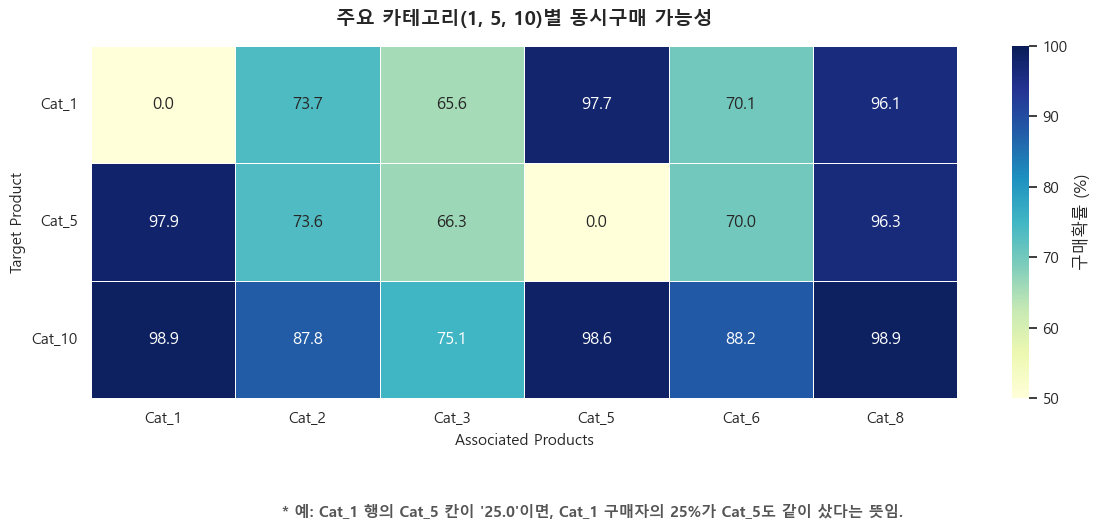

In [46]:
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12, 5)) 
sns.heatmap(final_matrix, 
            annot=True,       # 숫자 표시 
            fmt='.1f',        
            cmap='YlGnBu',    
            linewidths=.5, 
            vmin=50, vmax=100,   
            cbar_kws={'label': '구매확률 (%)'})
plt.title('주요 카테고리(1, 5, 10)별 동시구매 가능성', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Associated Products', fontsize=11)
plt.ylabel('Target Product', fontsize=11)
plt.yticks(rotation=0) # Y축 라벨 가로로

# 하단 설명
explanation = "* 예: Cat_1 행의 Cat_5 칸이 '25.0'이면, Cat_1 구매자의 25%가 Cat_5도 같이 샀다는 뜻임."
plt.figtext(0.5, -0.05, explanation, ha='center', fontsize=11, fontweight='bold', color='#555555')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 결론
>주력 상품인 Category 1을 구매하는 고객의 약 97%가 Category 5와 Category 8을 함께 구매하는 것으로 나타나, 이 세 카테고리를 '프리미엄 번들'로 묶어 판매하는 것이 객단가를 극대화하는 확실한 전략

cf.
(cat_1,cat_5), (cat_5, cat_1) 두 구간의 값이 다른 이유는 둘을 같이 산 고객의 수를 의미하는 분자는 같지만 "분모(기준이 되는 총 구매자 수)"가 다르기 때문

# 5. 분석 요약
Focus: 고객 데이터보다 제품 데이터의 매출 설명력이 더 높음 (파레토 7:3 법칙 확인).
Strategy: 많이 파는 것보다 비싸게 파는 것이 유리함 (고가 제품군이 매출의 50% 견인).
Target: 고가 전략의 핵심은 Product Category 1, 5, 10임.
Bundling: Category 1, 5, 8은 개별 상품이 아닌 ‘하나의 세트'처럼 소비됨. (Category 1 구매자의 **97%*가 Category 5, 8을 함께 구매하는 강력한 상호 의존성 확인.)

# 6. 향후 분석과제
- 고가 제품군 구매 고객 페르소나(Persona) 분석 : "Category 1을 사는 사람은 도대체 누구인가?"
배경: 'Category 1, 5, 8'에 집중 > 하지만 이 제품을 누구에게 마케팅할지 모르면 전략을 실행할 수 없음

- 지역별(City_Category) 및 거주 기간별 매출 최적화 : "어느 도시의 창고에 재고를 더 많이 쌓아야 하는가?"
배경: City_Category (A, B, C)와 Stay_In_Current_City_Years 변수가 활용되지 않음. 물류 효율화를 위해 필수적

# Appendix: 2-2 가설 검증

In [50]:
# [검증 1] Purchase 컬럼의 가격 변동성 확인 ("단가인가, 결제금액인가?")

# 제품별(Product_ID)로 Purchase 컬럼의 통계량 집계
# count: 판매 횟수, mean: 평균 결제액, std: 표준편차, nunique: 고유한 결제 금액의 수
product_stats = df.groupby('Product_ID')['Purchase'].agg(['count', 'mean', 'std', 'nunique'])

# 변동 계수(CV, Coefficient of Variation) 계산
# 금액대가 다른 제품 간의 변동성을 비교하기 위해 표준화한 지표
# CV가 0이면 가격 변동 없음, 클수록 변동 폭이 큼
product_stats['cv'] = product_stats['std'] / product_stats['mean']

# 분석 결과 
total_products = len(product_stats)
constant_price_products = len(product_stats[product_stats['nunique'] == 1]) # 가격이 딱 1개인 제품
varying_price_products = len(product_stats[product_stats['nunique'] > 1])   # 가격이 여러 개인 제품

# 가격 변동이 있는 제품들의 평균 변동성(CV) 
avg_cv_varying = product_stats[product_stats['nunique'] > 1]['cv'].mean()
print(f"[검증 1] 가격 변동성 현황 ")
print(f"전체 제품 수: {total_products}개")
print(f"가격 변동이 없는 제품 (Constant): {constant_price_products}개 ({constant_price_products/total_products*100:.1f}%)")
print(f"가격 변동이 있는 제품 (Varying): {varying_price_products}개 ({varying_price_products/total_products*100:.1f}%)")
print(f"변동이 있는 제품들의 평균 변동계수(CV): {avg_cv_varying:.2f} (약 {avg_cv_varying*100:.0f}%)")
print("-" * 50)


# [검증 2] 상위 20% 고매출 제품 vs 하위 80% 제품의 변동성 비교

# 1. 제품별 총 매출 계산 및 정렬 (파레토 법칙 기준 마련)
product_revenue = df.groupby('Product_ID', as_index=False)['Purchase'].sum()
product_revenue = product_revenue.sort_values(by='Purchase', ascending=False).reset_index(drop=True)
# 2. 상위 20% 기준점 설정
# 누적 제품 비율 계산 (1등부터 꼴등까지 줄 세운 후 비율 매기기)
product_revenue['rank_ratio'] = (product_revenue.index + 1) / len(product_revenue)
# 상위 20% 제품의 ID 리스트 
top20_product_ids = product_revenue[product_revenue['rank_ratio'] <= 0.20]['Product_ID'].values
# 3. 통계 데이터프레임(product_stats)에 'Top 20% 여부' 태깅
product_stats['is_top20'] = product_stats.index.isin(top20_product_ids)
# 4. 그룹별 변동계수(CV) 평균 비교
# 상위 20% 그룹과 나머지 그룹의 CV 평균을 각각 계산
cv_comparison = product_stats.groupby('is_top20')['cv'].mean()

print(f"\n[검증 2] 그룹별 가격 안정성 비교 ")
print(f"상위 20% 제품 (Core Target)의 평균 변동성: {cv_comparison[True]:.2f}")
print(f"하위 80% 제품 (Others)의 평균 변동성: {cv_comparison[False]:.2f}")

if cv_comparison[True] < cv_comparison[False]:
    print("\n>> 결론: 상위 20% 제품이 하위 제품보다 가격 변동성이 낮음 (가격 방어력이 좋거나 할인이 적음).")
    print(">> 따라서 Purchase의 평균을 '객단가'로 가정하고 전략을 수립하는 것은 타당함.")
else:
    print("\n>> 결론: 상위 20% 제품의 가격 변동성이 더 큼.")

[검증 1] 가격 변동성 현황 
전체 제품 수: 3631개
가격 변동이 없는 제품 (Constant): 144개 (4.0%)
가격 변동이 있는 제품 (Varying): 3487개 (96.0%)
변동이 있는 제품들의 평균 변동계수(CV): 0.32 (약 32%)
--------------------------------------------------

[검증 2] 그룹별 가격 안정성 비교 
상위 20% 제품 (Core Target)의 평균 변동성: 0.26
하위 80% 제품 (Others)의 평균 변동성: 0.33

>> 결론: 상위 20% 제품이 하위 제품보다 가격 변동성이 낮음 (가격 방어력이 좋거나 할인이 적음).
>> 따라서 Purchase의 평균을 '객단가'로 가정하고 전략을 수립하는 것은 타당함.


https://docs.google.com/presentation/d/1TWQnmdt-aRvnUo45MU9wzSwoQhwSVUz9dpI8DjZYxMU/edit?usp=sharing